In [90]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize
from src.strategy import momentum_trend_strategy, momentum_volatility_strategy, momentum_voluratio_strategy
from src.visualization import plot_performance, plot_features

In [91]:
base_df = get_data('INTU', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


# Features 

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


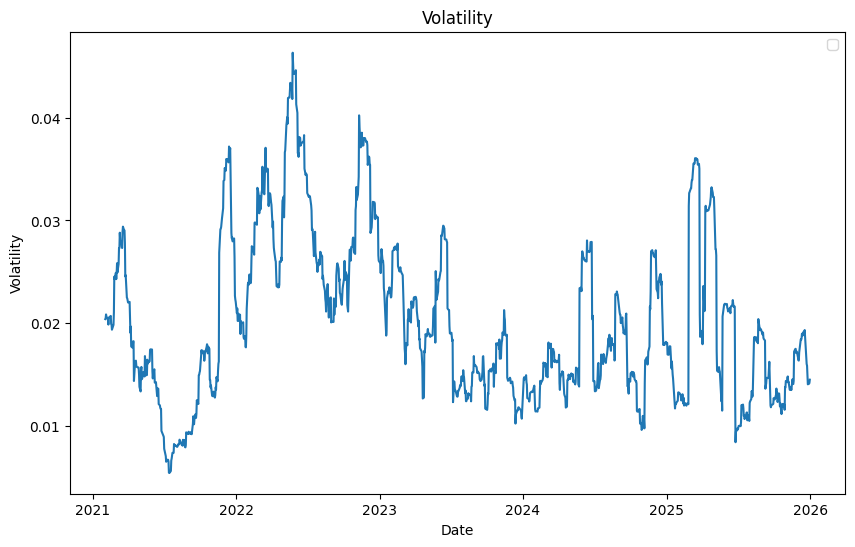

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


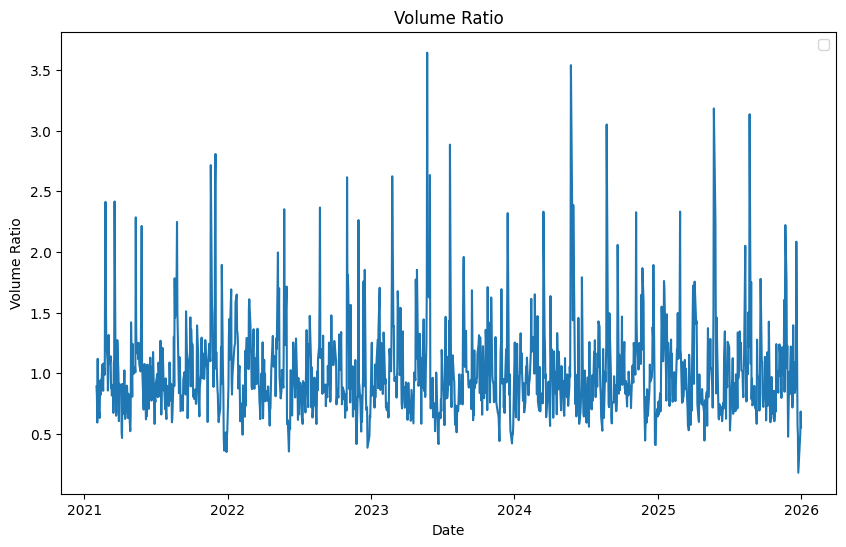

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


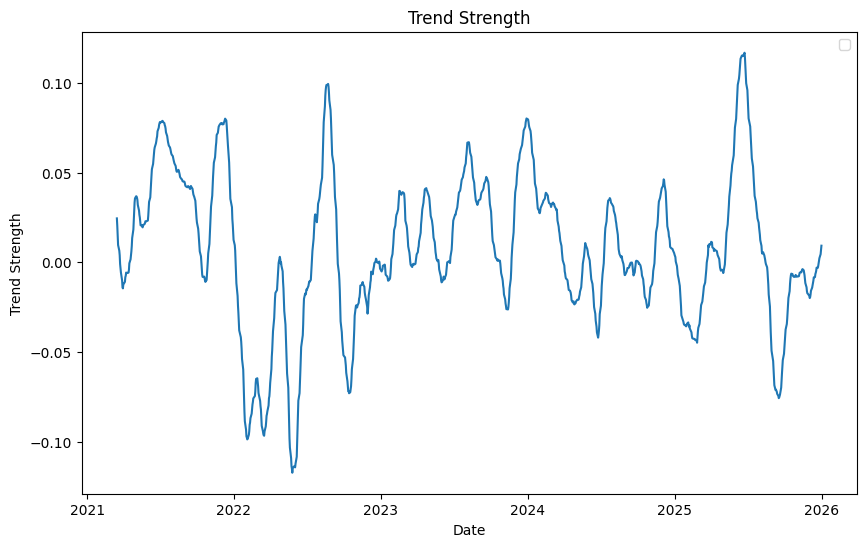

In [92]:
plot_features(base_df)

# Filtered Strategies

## Momentum + Trend Strategy

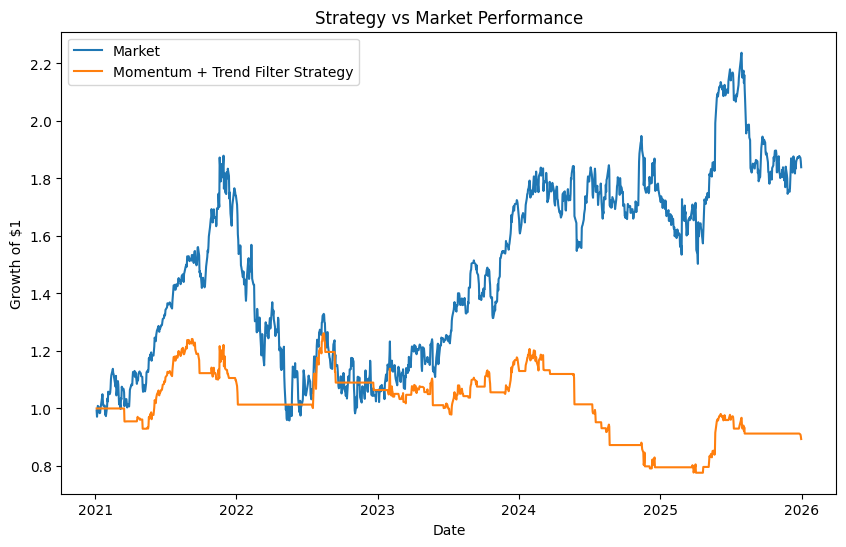

In [93]:
df = base_df.copy()
df = momentum_trend_strategy(df)
df = backtest(df)

plot_performance(df)

In [94]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.530248,0.339154,-0.490101
1,Momentum + Trend Filter,-0.043754,0.173054,-0.384555


## Momentum + Low Volatility Strategy

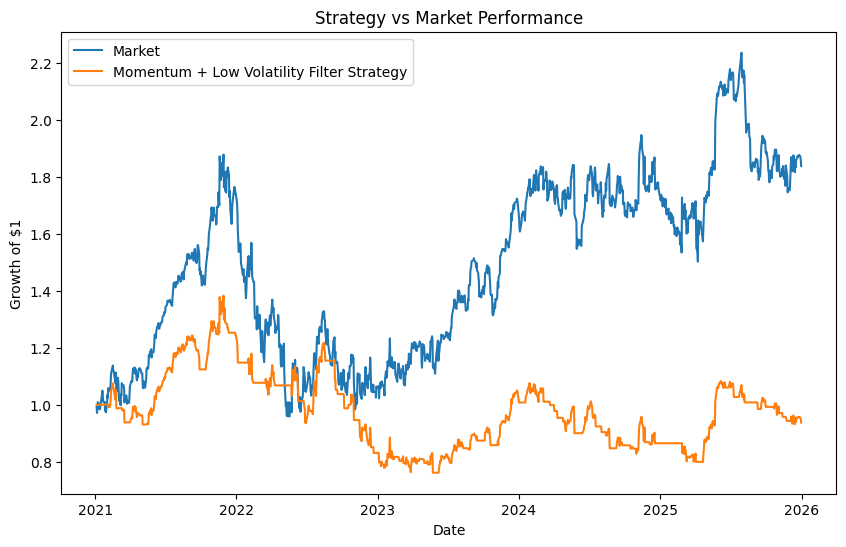

In [95]:
df = base_df.copy()
df = momentum_volatility_strategy(df)
df = backtest(df)

plot_performance(df)

In [96]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.530248,0.339154,-0.490101
1,Momentum + Low Volatility Filter,0.058977,0.230179,-0.449885


## Momentum + Volume Ratio Strategy

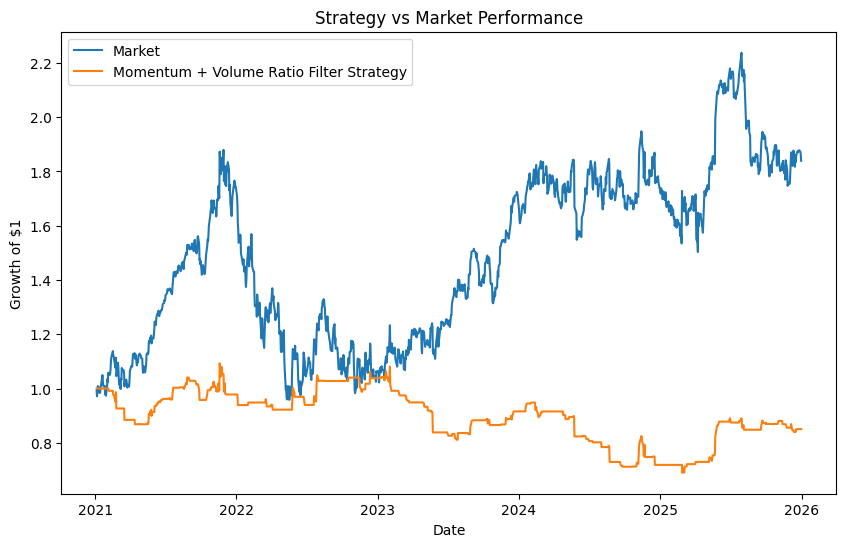

In [97]:
df = base_df.copy()
df = momentum_voluratio_strategy(df)
df = backtest(df)

plot_performance(df)

In [98]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.530248,0.339154,-0.490101
1,Momentum + Volume Ratio Filter,-0.127060,0.157683,-0.368820


# Parameter Testing

In [99]:
windows = range(1, 51)
strategies = [
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", []),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", []),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", [])
]

Momentum + Trend Strength
Market Returns Sharpe Ratio: 0.5302475606605866
Best Momentum + Trend Strength Strategy window: 24
Best Sharpe ratio: 0.4471


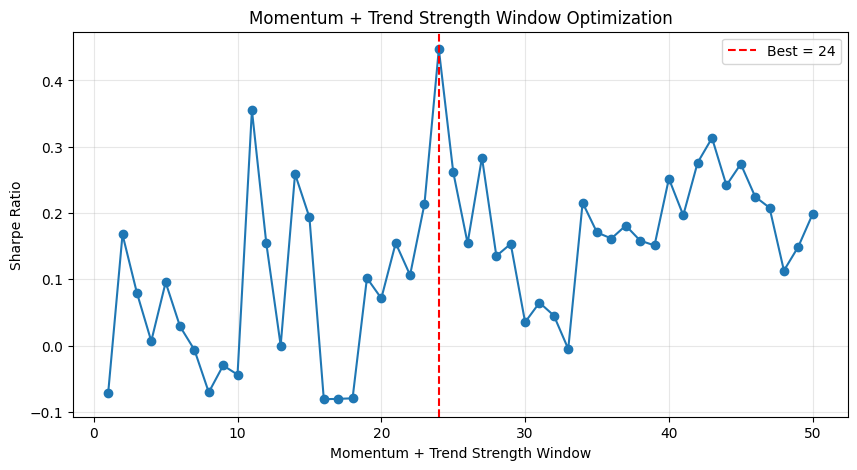

Momentum + Rolling Volatility
Market Returns Sharpe Ratio: 0.5302475606605866
Best Momentum + Rolling Volatility Strategy window: 42
Best Sharpe ratio: 0.5691


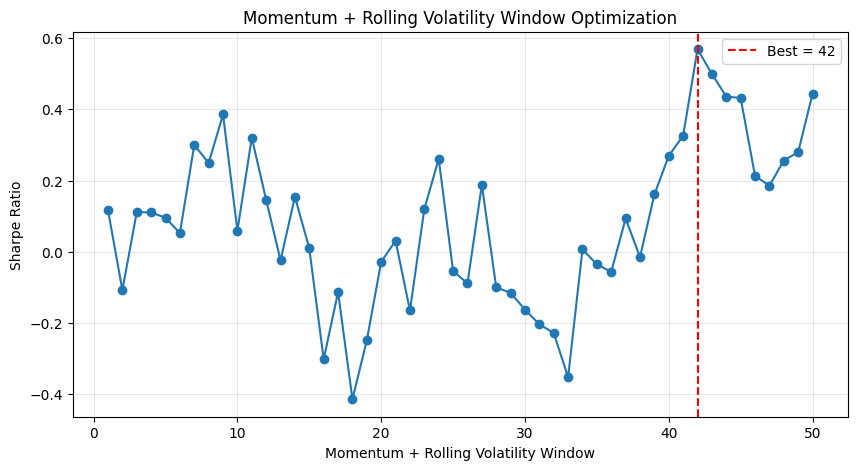

Momentum + Volume Ratio
Market Returns Sharpe Ratio: 0.5302475606605866
Best Momentum + Volume Ratio Strategy window: 11
Best Sharpe ratio: 0.2039


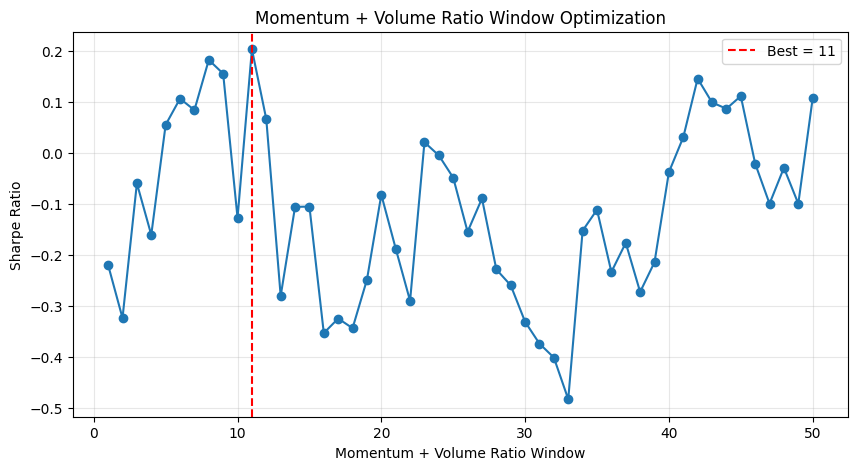

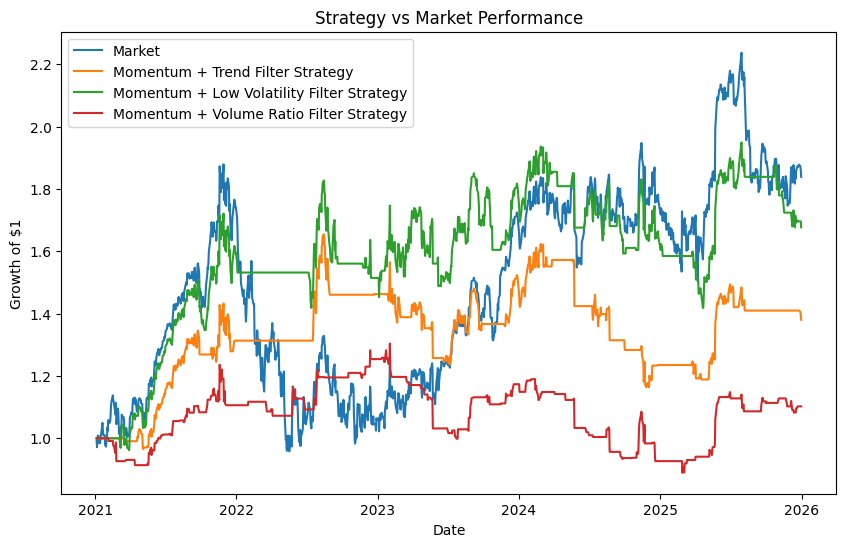

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.530248,0.339154,-0.490101
1,Momentum + Trend Filter,0.447094,0.181864,-0.296997
2,Momentum + Low Volatility Filter,0.569148,0.228432,-0.267504
3,Momentum + Volume Ratio Filter,0.203929,0.155024,-0.317954


In [100]:
df = base_df.copy()

optimize(df, strategies, windows)